In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import random
import time
import datetime
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split, RandomSampler, WeightedRandomSampler, Subset, SequentialSampler

from transformers import BertTokenizer, BertModel, BertForSequenceClassification, Trainer, TrainingArguments
from transformers import AdamW, get_linear_schedule_with_warmup

from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

BERT model with huggingface PyTorch library classification of program descriptions to outcome, genome, and impact area.

In [2]:
import os
os.listdir('/kaggle/input/')
#os.listdir

['Combined Data.xlsx']

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
input_file='/kaggle/input/Combined Data.xlsx'
print(f"Loading data from {input_file}")
data = pd.read_excel(input_file)

Loading data from /kaggle/input/Combined Data.xlsx


Pre-processing

In [5]:
data.dropna(inplace=True)
data['outcomeid'] = data['outcomeid'].astype(int) #float to int
#remove special characters from program description
#leave only letters, numbers, and some punctutation marks (colon, period, comma, apostraphe, hyphen)
data['programdescription'] = data['programdescription'].apply(lambda x: re.sub(r"[^A-Za-z0-9 :.,'-]+", "", x))

#mapping dict from outcomeid to outcome
outcomeid_to_outcome = dict(zip(data['outcomeid'], data['outcome']))

In [6]:
#encode labels (not consecutive)
#outcome encoder
outcome_encoder = LabelEncoder()
data['encoded_outcome_labels'] = outcome_encoder.fit_transform(data['outcomeid'])
num_outcome_labels = len(outcome_encoder.classes_)
print(f"Number of outcome labels: {num_outcome_labels}")

#genome encoder
genome_encoder = LabelEncoder()
data['encoded_genome_labels'] = genome_encoder.fit_transform(data['genome'])
num_genome_labels = len(genome_encoder.classes_)
print(f"Number of genome labels: {num_genome_labels}")

#impactarea encoder
impactarea_encoder = LabelEncoder()
data['encoded_impactarea_labels'] = impactarea_encoder.fit_transform(data['impactarea'])
num_impactarea_labels = len(impactarea_encoder.classes_)
print(f"Number of impact area labels: {num_impactarea_labels}")

Number of outcome labels: 289
Number of genome labels: 50
Number of impact area labels: 12


In [7]:
#extract sentences and labels as numpy ndarrays
sentences = data['programdescription'].tolist()
olabels = torch.tensor(data['encoded_outcome_labels'].tolist())
glabels=torch.tensor(data['encoded_genome_labels'].tolist())
ialabels=torch.tensor(data['encoded_impactarea_labels'].tolist())

To apply pre-trained BERT, data must be tokenized with BERT tokenizer.

Formatting for BERT
- All sentences must be single fixed length
- Max sentence length is 512 tokens

Tokenization and create TensorDataset

In [8]:
#load tokenizer and model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", do_lower_case=True)

def tokenize_data(sentences, max_length=240):
    input_ids = []
    attention_masks = []
    for sent in sentences:
        encoded_dict = tokenizer.encode_plus(
            sent,
            add_special_tokens=True, #add [cls] and [sep]
            max_length=max_length, #pad/truncate sentences
            pad_to_max_length=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        input_ids.append(encoded_dict['input_ids']) #add encoded sentence to list
        attention_masks.append(encoded_dict['attention_mask']) #add attention mask

    #convert lists to tensors
    return torch.cat(input_ids), torch.cat(attention_masks)

#apply tokenization
input_ids, attention_masks = tokenize_data(sentences)

#convert labels to tensors
outcome_labels = torch.tensor(olabels)
genome_labels = torch.tensor(glabels)
ia_labels = torch.tensor(ialabels)
#create TensorDataset
dataset = TensorDataset(input_ids, attention_masks, outcome_labels, genome_labels, ia_labels)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:2673: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(
<ipython-input-8-238ff336b92b>:26: UserWarning: To copy construct from a tensor, it is recommended 

In [9]:
#count occurrences of each outcome label
label_counts = Counter(outcome_labels.numpy())
#print(label_counts)
#check if any class has only 1 sample
min_class_size = min(label_counts.values())
#print(min_class_size)
#decide whether to use stratification
stratify_option = outcome_labels.numpy() if min_class_size > 1 else None
#print(stratify_option)

In [10]:
train_idx, val_idx = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    random_state=42,
    stratify=stratify_option
)
#use indices to split the dataset
train_dataset = TensorDataset(
    input_ids[train_idx],
    attention_masks[train_idx],
    outcome_labels[train_idx],
    genome_labels[train_idx],
    ia_labels[train_idx]
)
val_dataset = TensorDataset(
    input_ids[val_idx],
    attention_masks[val_idx],
    outcome_labels[val_idx],
    genome_labels[val_idx],
    ia_labels[val_idx]
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 8680
Validation samples: 2171


create iterator using torch DataLoader to save on memory during training

-with iterator datset doesn't need to be loaded into memory

In [12]:
class HierarchicalBertClassifier(nn.Module):
    def __init__(self, num_impactarea_labels, num_genome_labels, num_outcome_labels, hidden_size=256, dropout_rate=0.3):
        super(HierarchicalBertClassifier, self).__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(dropout_rate)

        #impact area prediction
        self.ia_hidden = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        self.ia_classifier = nn.Linear(hidden_size, num_impactarea_labels)
        #layer to extract ia features
        self.ia_feature_extractor = nn.Linear(num_impactarea_labels, hidden_size)

        #genome prediction (conditioned on impact area)
        self.genome_hidden = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size + num_impactarea_labels, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        self.genome_classifier = nn.Linear(hidden_size, num_genome_labels)
        #layer to extract genome features
        self.genome_feature_extractor = nn.Linear(num_genome_labels, hidden_size)

        #outcome prediction (conditioned on impact area & genome)
        self.cross_attention = nn.MultiheadAttention(hidden_size, num_heads=4)
        self.outcome_hidden = nn.Sequential(
            nn.Linear(self.bert.config.hidden_size + num_impactarea_labels + num_genome_labels + hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        self.outcome_classifier = nn.Linear(hidden_size, num_outcome_labels)


    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        bert_output = self.dropout(bert_output)

        #impact area prediction
        ia_hidden = self.ia_hidden(bert_output)
        ia_logits = self.ia_classifier(ia_hidden)
        #get probs for ia to pass to next level
        ia_probs= F.softmax(ia_logits, dim=1)
        #extract more features from ia probs
        ia_features = self.ia_feature_extractor(ia_probs)

        #genome prediction (with impact area info)
        genome_input = torch.cat([bert_output, ia_probs], dim=1)
        genome_hidden = self.genome_hidden(genome_input)
        genome_logits = self.genome_classifier(genome_hidden)
        #get probs for genome to pass to next level
        genome_probs = F.softmax(genome_logits, dim=1)

        #extract more features from genome probs
        genome_features = self.genome_feature_extractor(genome_probs)

        #cross atttention between genome & ia features
        genome_features_reshaped=genome_features.unsqueeze(0)
        ia_features_reshaped= ia_features.unsqueeze(0)

        attended_features, _ = self.cross_attention(
        genome_features_reshaped,  # query
        ia_features_reshaped,      # key
        ia_features_reshaped       # value
       )
        attended_features = attended_features.squeeze(0)

        #outcome prediction
        outcome_input = torch.cat([bert_output, ia_probs, genome_probs, attended_features], dim=1)
        outcome_hidden = self.outcome_hidden(outcome_input)
        outcome_logits = self.outcome_classifier(outcome_hidden)

        return ia_logits, genome_logits, outcome_logits

    def predict(self, input_ids, attention_mask):
        ia_logits, genome_logits, outcome_logits = self.forward(input_ids, attention_mask)

        ia_preds = torch.argmax(ia_logits, dim=1)
        genome_preds = torch.argmax(genome_logits, dim=1)
        outcome_preds = torch.argmax(outcome_logits, dim=1)

        return ia_preds, genome_preds, outcome_preds


In [13]:
model = HierarchicalBertClassifier(
    num_impactarea_labels=12,
    num_genome_labels=50,
    num_outcome_labels=289,
    hidden_size=256,
    dropout_rate=0.3)
model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

HierarchicalBertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [14]:
#DataLoader
batch_size=16
train_dataloader=DataLoader(
    train_dataset,
    batch_size=batch_size
)
validation_dataloader=DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=batch_size
)

In [15]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
parameter_groups = [
    #lowest learning rate
    {'params': model.bert.parameters(), 'lr': 2e-5},

    {'params': model.ia_hidden.parameters(), 'lr': 3e-5},
    {'params': model.ia_classifier.parameters(), 'lr': 3e-5},

    {'params': model.genome_hidden.parameters(), 'lr': 3e-5},
    {'params': model.genome_classifier.parameters(), 'lr': 3e-5},

    #highest learning rate
    {'params': model.outcome_hidden.parameters(), 'lr': 2e-4},
    {'params': model.outcome_classifier.parameters(), 'lr': 2e-4},

    {'params': model.ia_feature_extractor.parameters(), 'lr': 7e-5},
    {'params': model.genome_feature_extractor.parameters(), 'lr': 7e-5}
]

#optimizer and scheduler
optimizer = AdamW(model.parameters(),
                  lr=3e-5,
                  eps=1e-8)

#trainable parameter for uncertainty-based weighting (Kendall's multi-task loss)
#learn weights at each task
outcome_log_var = torch.nn.Parameter(torch.tensor(0.0, device=device, requires_grad=True))
genome_log_var = torch.nn.Parameter(torch.tensor(0.0, device=device, requires_grad=True))
ia_log_var = torch.nn.Parameter(torch.tensor(0.0, device=device, requires_grad=True))
#add log variance parameters
optimizer.add_param_group({'params': [outcome_log_var, genome_log_var, ia_log_var], 'lr': 2e-5})

epochs=30
total_steps=len(train_dataloader)*epochs

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2,
    verbose=True,
    threshold=0.001,
    min_lr=1e-6
)

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [16]:
#loss function
#loss_fn = torch.nn.CrossEntropyLoss()
class FocalLoss(nn.Module):
#for class imbalance
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        #standard cross entropy loss
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        #get probabilities
        pt = torch.exp(-ce_loss)

        #apply focusing parameter
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        #apply alpha weighting if provided
        if self.alpha is not None:
            if isinstance(self.alpha, torch.Tensor):
                #if alpha is tensor, then specified per-class
                #select alpha based on target class
                alpha_t = self.alpha.gather(0, targets)
                focal_loss = alpha_t * focal_loss
            else:
                #if alpha is scalar, apply universally
                focal_loss = self.alpha * focal_loss

        #reduction
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

ia_loss_fn = FocalLoss(gamma=2.0)
genome_loss_fn = FocalLoss(gamma=2.0)
outcome_loss_fn = FocalLoss(gamma=4.0)

In [18]:
#early stopping parameters
best_f1 = 0
patience = 3
epochs_no_improve = 0
best_model_path = '/kaggle/working/best_hierarchical_model_412.pt'

#hard negative mining settings
use_hard_negatives = False
hard_negative_start_epoch = 3
hard_negative_frequency = 2

#hierarchical loss - co-occurance stats
ia_outcome_counts = torch.zeros(num_impactarea_labels, num_outcome_labels)
genome_outcome_counts = torch.zeros(num_genome_labels, num_outcome_labels)

for i in range(len(train_dataset)):
    _, _, outcome_label, genome_label, ia_label = train_dataset[i]
    ia_outcome_counts[ia_label][outcome_label] += 1
    genome_outcome_counts[genome_label][outcome_label] += 1

#convert to probability matrices
ia_outcome_matrix = ia_outcome_counts / (ia_outcome_counts.sum(dim=1, keepdim=True) + 1e-10)
genome_outcome_matrix = genome_outcome_counts / (genome_outcome_counts.sum(dim=1, keepdim=True) + 1e-10)
#move to device
ia_outcome_matrix = ia_outcome_matrix.to(device)
genome_outcome_matrix = genome_outcome_matrix.to(device)


#helpers
def format_time(elapsed):
#takes time in seconds, returns string hh:mm:ss
    elapsed_rounded = int(round((elapsed)))
    return str(datetime.timedelta(seconds=elapsed_rounded))

#calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)


Train classification model

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [21]:
seed_val = 42
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

training_stats = []
total_t0 = time.time()

for epoch_i in range(0, epochs):
    print(f"\n======== Epoch {epoch_i + 1} / {epochs} ========")
    #det if hard negatives needed at end of epoch
    calculate_hard_negatives = (epoch_i + 1) >= hard_negative_start_epoch and (epoch_i + 1) % hard_negative_frequency == 0
    print('Training...')
    t0 = time.time() #how long training epoch takes
    total_train_loss= 0 #reset total loss for epoch
    model.train() #model training mode

    #track metrics for each task
    ia_correct, genome_correct, outcome_correct = 0, 0, 0
    total_examples = 0

    #for each training batch
    for step, batch in enumerate(train_dataloader):
        if step % 40 == 0 and step != 0: #update progress every 40 batches
            elapsed = format_time(time.time() - t0) #elpased time in minutes
            print(f'  Batch {step:>5,} of {len(train_dataloader):>5,}. Elapsed: {elapsed}.') #report progress

        #unpack training batch from dataloader
        input_ids, attention_mask, outcome_labels, genome_labels, ia_labels = [b.to(device) for b in batch]
        #clear previously calculated gradients before backward pass
        optimizer.zero_grad()
        #forward pass
        ia_logits, genome_logits, outcome_logits = model(input_ids, attention_mask)

        #accumulate training loss over all batches
        ia_loss = ia_loss_fn(ia_logits, ia_labels)
        genome_loss = genome_loss_fn(genome_logits, genome_labels)
        outcome_loss = outcome_loss_fn(outcome_logits, outcome_labels)

        #consistency loss
        ia_probs_detached = F.softmax(ia_logits, dim=1).detach()
        genome_probs_detached = F.softmax(genome_logits, dim=1).detach()
        #predicts outcomes based on impact area and genome
        hierarchical_prediction = (ia_probs_detached @ ia_outcome_matrix +
                              genome_probs_detached @ genome_outcome_matrix)
        #penalize differences between direct prediction and hierarchical prediction
        consistency_loss = torch.mean(torch.abs(outcome_logits - hierarchical_prediction))

        #combine losses using uncertainty weighting
        total_batch_loss = 0
        total_batch_loss += torch.exp(-ia_log_var) * ia_loss + ia_log_var
        total_batch_loss += torch.exp(-genome_log_var) * genome_loss + genome_log_var
        #curriculum learning
        #gradually increase over first 5 epochs for 1-3
        epoch_factor = min(1.0, epoch_i / 5)
        outcome_weight = 1.0 + 2.0 * epoch_factor
        total_batch_loss += outcome_weight * (torch.exp(-outcome_log_var) * outcome_loss + outcome_log_var)
        total_batch_loss += 0.1 * consistency_loss #add consistency loss

        total_batch_loss.backward() #backward pass
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) #clip gradiants
        optimizer.step() #update parameters & take step using computed gradient
        #scheduler.step() #update lr

        total_train_loss += total_batch_loss.item() #update total loss
        total_examples += input_ids.size(0) #count batch samples

        #get predictions & track accuracy
        _, ia_preds = torch.max(ia_logits, dim=1)
        _, genome_preds = torch.max(genome_logits, dim=1)
        _, outcome_preds = torch.max(outcome_logits, dim=1)
        #count correct predictions
        ia_correct += (ia_preds == ia_labels).sum().item()
        genome_correct += (genome_preds == genome_labels).sum().item()
        outcome_correct += (outcome_preds == outcome_labels).sum().item()

    #calc training metrics
    avg_train_loss = total_train_loss / len(train_dataloader)
    ia_accuracy = ia_correct / total_examples
    genome_accuracy = genome_correct / total_examples
    outcome_accuracy = outcome_correct / total_examples

    training_time = format_time(time.time() - t0)
    print(f"  Average training loss: {avg_train_loss:.4f}")
    print(f"  Impact Area Accuracy: {ia_accuracy:.4f}")
    print(f"  Genome Accuracy: {genome_accuracy:.4f}")
    print(f"  Outcome Accuracy: {outcome_accuracy:.4f}")
    print(f"  Training took: {training_time}")

    print(f"  Learned Log Variances: IA={ia_log_var.item():.4f}, Genome={genome_log_var.item():.4f}, Outcome={outcome_log_var.item():.4f}")

    # ========================================
    #               Validation
    # ========================================
    print("\nRunning Validation...")
    t0 = time.time()
    model.eval()

    total_eval_loss = 0
    val_ia_correct, val_genome_correct, val_outcome_correct = 0, 0, 0
    val_total = 0
    #all predictions
    all_ia_preds = []
    all_ia_labels = []
    all_genome_preds = []
    all_genome_labels = []
    all_outcome_preds = []
    all_outcome_labels = []


    with torch.no_grad():
      for batch in validation_dataloader:
        input_ids, attention_mask, outcome_labels, genome_labels, ia_labels = [b.to(device) for b in batch]

        #forward pass
        ia_logits, genome_logits, outcome_logits = model(input_ids, attention_mask)

        #calc validation loss
        ia_loss = ia_loss_fn(ia_logits, ia_labels)
        genome_loss = genome_loss_fn(genome_logits, genome_labels)
        outcome_loss = outcome_loss_fn(outcome_logits, outcome_labels)

        #combine losses using weighting
        eval_loss = 0
        eval_loss += torch.exp(-ia_log_var) * ia_loss + ia_log_var
        eval_loss += torch.exp(-genome_log_var) * genome_loss + genome_log_var
        eval_loss += torch.exp(-outcome_log_var) * outcome_loss + outcome_log_var

        total_eval_loss += eval_loss.item()

        #accuracy
        val_total += input_ids.size(0)
        #get predictions
        _, ia_preds = torch.max(ia_logits, dim=1)
        _, genome_preds = torch.max(genome_logits, dim=1)
        _, outcome_preds = torch.max(outcome_logits, dim=1)

        all_ia_preds.extend(ia_preds.cpu().numpy())
        all_ia_labels.extend(ia_labels.cpu().numpy())
        all_genome_preds.extend(genome_preds.cpu().numpy())
        all_genome_labels.extend(genome_labels.cpu().numpy())
        all_outcome_preds.extend(outcome_preds.cpu().numpy())
        all_outcome_labels.extend(outcome_labels.cpu().numpy())

        val_ia_correct += (ia_preds == ia_labels).sum().item()
        val_genome_correct += (genome_preds == genome_labels).sum().item()
        val_outcome_correct += (outcome_preds == outcome_labels).sum().item()

    #validation metrics
    avg_val_loss = total_eval_loss / len(validation_dataloader)
    val_ia_accuracy = val_ia_correct / val_total
    val_genome_accuracy = val_genome_correct / val_total
    val_outcome_accuracy = val_outcome_correct / val_total
    
    ia_precision = precision_score(all_ia_labels, all_ia_preds, average='macro')
    ia_recall = recall_score(all_ia_labels, all_ia_preds, average='macro')
    genome_precision = precision_score(all_genome_labels, all_genome_preds, average='macro')
    genome_recall = recall_score(all_genome_labels, all_genome_preds, average='macro')
    outcome_precision = precision_score(all_outcome_labels, all_outcome_preds, average='macro')
    outcome_recall = recall_score(all_outcome_labels, all_outcome_preds, average='macro')
    
    validation_time = format_time(time.time() - t0)

    print(f"  Validation Loss: {avg_val_loss:.4f}")
    print(f"  Impact Area - Accuracy: {val_ia_accuracy:.4f}, Precision: {ia_precision:.4f}, Recall: {ia_recall:.4f}")
    print(f"  Genome - Accuracy: {val_genome_accuracy:.4f}, Precision: {genome_precision:.4f}, Recall: {genome_recall:.4f}")
    print(f"  Outcome - Accuracy: {val_outcome_accuracy:.4f}, Precision: {outcome_precision:.4f}, Recall: {outcome_recall:.4f}")
    print(f"  Validation took: {validation_time}")

    #calc F1 score for early stopping (after the validation loop)
    outcome_f1 = f1_score(all_outcome_labels, all_outcome_preds, average='macro')
    print(f"Outcome Macro F1 Score: {outcome_f1:.4f}")
    #step scheduler with f1 score
    scheduler.step(outcome_f1)

    # ========================================
    #        Hard Negative Mining
    # ========================================
    if calculate_hard_negatives:
        print("\nCalculating hard negatives for next epoch...")
        t_neg = time.time()

        #sample % training data for hard negative mining
        sample_percent = 0.3
        sample_size = int(sample_percent * len(train_dataset))
        sample_indices = torch.randperm(len(train_dataset))[:sample_size]

        #create a subset dataset
        from torch.utils.data import Subset
        sampled_dataset = Subset(train_dataset, sample_indices)

        #store loss values for all training examples
        all_losses = torch.ones(len(train_dataset))
        model.eval() #reuse model in eval mode
        hard_neg_batch_size = 4 #small batch size (memory)

        with torch.no_grad():
            #create dataloader for the subset
            hard_neg_dataloader = DataLoader(
                sampled_dataset,
                batch_size=hard_neg_batch_size,
                shuffle=False
            )
            for i, batch in enumerate(hard_neg_dataloader):
                input_ids, attention_mask, outcome_labels, genome_labels, ia_labels = [b.to(device) for b in batch]
                #forward pass
                ia_logits, genome_logits, outcome_logits = model(input_ids, attention_mask)

                #get per-example loss and move to CPU (memory)
                batch_losses = F.cross_entropy(outcome_logits, outcome_labels, reduction='none').cpu()

                #map batch indices to original dataset indices
                batch_start = i * hard_neg_batch_size
                batch_end = min((i+1) * hard_neg_batch_size, sample_size)
                original_indices = sample_indices[batch_start:batch_end]

                #store losses in corresponding positions
                all_losses[original_indices] = batch_losses

                #clear CUDA cache periodically (memory)
                if i % 10 == 0:
                    torch.cuda.empty_cache()

        #create example weights based on loss values
        temperature = 2.0  #control" peakiness" of distribution
        loss_weights = torch.softmax(all_losses / temperature, dim=0) * len(train_dataset)

        weighted_sampler = WeightedRandomSampler(
            weights=loss_weights,
            num_samples=len(train_dataset),
            replacement=True
        )

        #create new dataloader with weighted sampling
        train_dataloader = DataLoader(
            train_dataset,
            sampler=weighted_sampler,
            batch_size=batch_size
        )

        use_hard_negatives = True

        hard_neg_time = format_time(time.time() - t_neg)
        print(f"Hard negative mining completed in {hard_neg_time}")
        print(f"Sampled {sample_percent:.1%} of data ({sample_size} examples) for hard negative mining")
        print(f"Min weight: {loss_weights.min().item():.4f}, Max weight: {loss_weights.max().item():.4f}")
        print(f"Using hard negative sampling for next epoch")

    #check if best model so far
    if outcome_f1 > best_f1:
        print(f"New best model! F1 improved from {best_f1:.4f} to {outcome_f1:.4f}")
        best_f1 = outcome_f1

        #save best model
        torch.save({
            'model': model,
            'outcome_encoder': outcome_encoder,
            'genome_encoder': genome_encoder,
            'impactarea_encoder': impactarea_encoder,
            'ia_log_var': ia_log_var,
            'genome_log_var': genome_log_var,
            'outcome_log_var': outcome_log_var,
            'epoch': epoch_i,
            'f1_score': outcome_f1
        }, best_model_path)

        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"F1 did not improve. Best: {best_f1:.4f}, Current: {outcome_f1:.4f}")
        print(f"Epochs without improvement: {epochs_no_improve}/{patience}")

    #early stopping check
    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch_i + 1} epochs")
        break

    training_stats.append({
    'epoch': epoch_i + 1,
    'Training Loss': avg_train_loss,
    'Val. Loss': avg_val_loss,
    'Val. IA Accuracy': val_ia_accuracy,
    'Val. Genome Accuracy': val_genome_accuracy,
    'Val. Outcome Accuracy': val_outcome_accuracy,
    'Val. IA Precision': ia_precision,
    'Val. IA Recall': ia_recall,
    'Val. Genome Precision': genome_precision,
    'Val. Genome Recall': genome_recall,
    'Val. Outcome Precision': outcome_precision,
    'Val. Outcome Recall': outcome_recall,
    'Outcome F1 Score': outcome_f1,
    'IA Log Var': ia_log_var.item(),
    'Genome Log Var': genome_log_var.item(),
    'Outcome Log Var': outcome_log_var.item(),
    'Training Time': training_time,
    'Validation Time': validation_time,
    'Using Hard Negatives': use_hard_negatives
    })

print(f"\nTraining complete!")
print(f"Total training took {format_time(time.time() - total_t0)}")
print(f"Best outcome F1 score: {best_f1:.4f}")

best_checkpoint = torch.load(best_model_path, weights_only=False)
best_model = best_checkpoint['model']
print(f"Best model was from epoch {best_checkpoint['epoch'] + 1}")

torch.save({
    'model': best_model,
    'ia_log_var': best_checkpoint['ia_log_var'],
    'genome_log_var': best_checkpoint['genome_log_var'],
    'outcome_log_var': best_checkpoint['outcome_log_var'],
    'outcome_encoder': best_checkpoint['outcome_encoder'],
    'genome_encoder': best_checkpoint['genome_encoder'],
    'impactarea_encoder': best_checkpoint['impactarea_encoder'],
    'epoch': epoch_i,
    'f1_score': outcome_f1,
    'ia_precision': ia_precision,
    'ia_recall': ia_recall, 
    'genome_precision': genome_precision,
    'genome_recall': genome_recall,
    'outcome_precision': outcome_precision,
    'outcome_recall': outcome_recall,
    'model_class' : HierarchicalBertClassifier
}, 'hierarchical_bert_model_412.pt')


======== Epoch 1 / 30 ========
Training...
  Batch    40 of   543. Elapsed: 0:00:16.
  Batch    80 of   543. Elapsed: 0:00:31.
  Batch   120 of   543. Elapsed: 0:00:46.
  Batch   160 of   543. Elapsed: 0:01:01.
  Batch   200 of   543. Elapsed: 0:01:16.
  Batch   240 of   543. Elapsed: 0:01:31.
  Batch   280 of   543. Elapsed: 0:01:46.
  Batch   320 of   543. Elapsed: 0:02:01.
  Batch   360 of   543. Elapsed: 0:02:16.
  Batch   400 of   543. Elapsed: 0:02:31.
  Batch   440 of   543. Elapsed: 0:02:46.
  Batch   480 of   543. Elapsed: 0:03:01.
  Batch   520 of   543. Elapsed: 0:03:16.
  Average training loss: 8.5033
  Impact Area Accuracy: 0.6899
  Genome Accuracy: 0.3112
  Outcome Accuracy: 0.0641
  Training took: 0:03:25
  Learned Log Variances: IA=-0.0047, Genome=0.0076, Outcome=0.0102

Running Validation...


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


  Validation Loss: 6.3358
  Impact Area - Accuracy: 0.8434, Precision: 0.7622, Recall: 0.7277
  Genome - Accuracy: 0.5394, Precision: 0.2409, Recall: 0.2769
  Outcome - Accuracy: 0.1152, Precision: 0.0038, Recall: 0.0261
  Validation took: 0:00:15
Outcome Macro F1 Score: 0.0062
New best model! F1 improved from 0.0000 to 0.0062

======== Epoch 2 / 30 ========
Training...
  Batch    40 of   543. Elapsed: 0:00:15.
  Batch    80 of   543. Elapsed: 0:00:30.
  Batch   120 of   543. Elapsed: 0:00:45.
  Batch   160 of   543. Elapsed: 0:01:00.
  Batch   200 of   543. Elapsed: 0:01:15.
  Batch   240 of   543. Elapsed: 0:01:30.
  Batch   280 of   543. Elapsed: 0:01:45.
  Batch   320 of   543. Elapsed: 0:02:00.
  Batch   360 of   543. Elapsed: 0:02:15.
  Batch   400 of   543. Elapsed: 0:02:30.
  Batch   440 of   543. Elapsed: 0:02:45.
  Batch   480 of   543. Elapsed: 0:03:00.
  Batch   520 of   543. Elapsed: 0:03:15.
  Average training loss: 7.2429
  Impact Area Accuracy: 0.8808
  Genome Accuracy:

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


  Validation Loss: 4.8438
  Impact Area - Accuracy: 0.8687, Precision: 0.8733, Recall: 0.8336
  Genome - Accuracy: 0.6467, Precision: 0.3520, Recall: 0.3995
  Outcome - Accuracy: 0.1907, Precision: 0.0167, Recall: 0.0576
  Validation took: 0:00:15
Outcome Macro F1 Score: 0.0227
New best model! F1 improved from 0.0062 to 0.0227

======== Epoch 3 / 30 ========
Training...
  Batch    40 of   543. Elapsed: 0:00:15.
  Batch    80 of   543. Elapsed: 0:00:30.
  Batch   120 of   543. Elapsed: 0:00:45.
  Batch   160 of   543. Elapsed: 0:01:00.
  Batch   200 of   543. Elapsed: 0:01:15.
  Batch   240 of   543. Elapsed: 0:01:30.
  Batch   280 of   543. Elapsed: 0:01:45.
  Batch   320 of   543. Elapsed: 0:02:00.
  Batch   360 of   543. Elapsed: 0:02:15.
  Batch   400 of   543. Elapsed: 0:02:30.
  Batch   440 of   543. Elapsed: 0:02:45.
  Batch   480 of   543. Elapsed: 0:03:00.
  Batch   520 of   543. Elapsed: 0:03:15.
  Average training loss: 6.9423
  Impact Area Accuracy: 0.9197
  Genome Accuracy:

...

  Validation Loss: 2.0398
  Impact Area - Accuracy: 0.8835, Precision: 0.8752, Recall: 0.8650
  Genome - Accuracy: 0.8351, Precision: 0.8467, Recall: 0.8388
  Outcome - Accuracy: 0.6679, Precision: 0.7477, Recall: 0.7237
  Validation took: 0:00:15
Outcome Macro F1 Score: 0.7187

Calculating hard negatives for next epoch...
Hard negative mining completed in 0:00:20
Sampled 30.0% of data (2604 examples) for hard negative mining
Min weight: 0.6767, Max weight: 29.5725
Using hard negative sampling for next epoch
F1 did not improve. Best: 0.7244, Current: 0.7187
Epochs without improvement: 1/3

======== Epoch 29 / 30 ========
Training...
  Batch    40 of   543. Elapsed: 0:00:15.
  Batch    80 of   543. Elapsed: 0:00:30.
  Batch   120 of   543. Elapsed: 0:00:45.
  Batch   160 of   543. Elapsed: 0:01:00.
  Batch   200 of   543. Elapsed: 0:01:15.
  Batch   240 of   543. Elapsed: 0:01:30.
  Batch   280 of   543. Elapsed: 0:01:45.
  Batch   320 of   543. Elapsed: 0:02:00.
  Batch   360 of   543.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


  Validation Loss: 2.0495
  Impact Area - Accuracy: 0.8839, Precision: 0.8789, Recall: 0.8675
  Genome - Accuracy: 0.8379, Precision: 0.8616, Recall: 0.8491
  Outcome - Accuracy: 0.6720, Precision: 0.7479, Recall: 0.7232
  Validation took: 0:00:15
Outcome Macro F1 Score: 0.7149
F1 did not improve. Best: 0.7244, Current: 0.7149
Epochs without improvement: 2/3

======== Epoch 30 / 30 ========
Training...
  Batch    40 of   543. Elapsed: 0:00:15.
  Batch    80 of   543. Elapsed: 0:00:30.
  Batch   120 of   543. Elapsed: 0:00:45.
  Batch   160 of   543. Elapsed: 0:01:00.
  Batch   200 of   543. Elapsed: 0:01:15.
  Batch   240 of   543. Elapsed: 0:01:30.
  Batch   280 of   543. Elapsed: 0:01:45.
  Batch   320 of   543. Elapsed: 0:02:00.
  Batch   360 of   543. Elapsed: 0:02:15.
  Batch   400 of   543. Elapsed: 0:02:30.
  Batch   440 of   543. Elapsed: 0:02:45.
  Batch   480 of   543. Elapsed: 0:03:00.
  Batch   520 of   543. Elapsed: 0:03:15.
  Average training loss: 0.0317
  Impact Area Ac

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


  Validation Loss: 2.0649
  Impact Area - Accuracy: 0.8844, Precision: 0.8689, Recall: 0.8695
  Genome - Accuracy: 0.8388, Precision: 0.8525, Recall: 0.8385
  Outcome - Accuracy: 0.6697, Precision: 0.7493, Recall: 0.7247
  Validation took: 0:00:15
Outcome Macro F1 Score: 0.7169

Calculating hard negatives for next epoch...
Hard negative mining completed in 0:00:20
Sampled 30.0% of data (2604 examples) for hard negative mining
Min weight: 0.6761, Max weight: 25.4240
Using hard negative sampling for next epoch
F1 did not improve. Best: 0.7244, Current: 0.7169
Epochs without improvement: 3/3
Early stopping triggered after 30 epochs

Training complete!
Total training took 1:54:19
Best outcome F1 score: 0.7244
Best model was from epoch 27


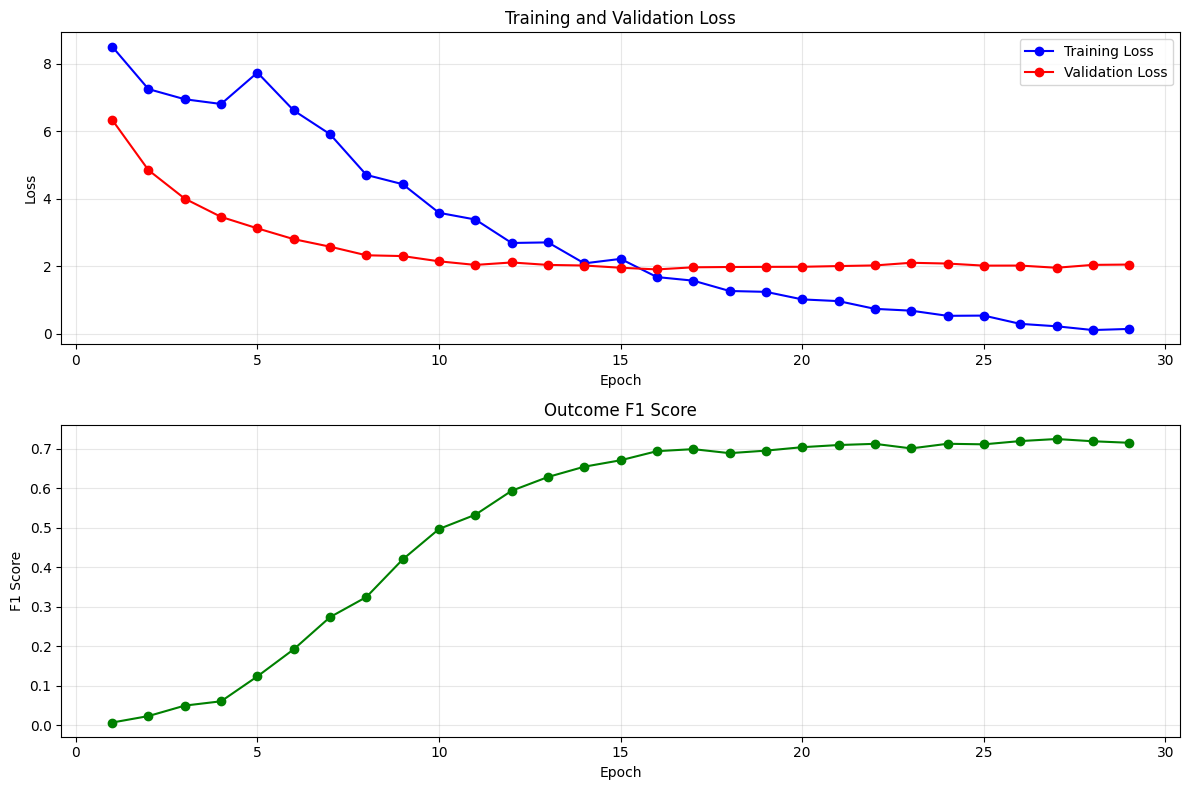

In [22]:
epochs= [stats['epoch'] for stats in training_stats]
train_loss= [stats['Training Loss'] for stats in training_stats]
val_loss= [stats['Val. Loss'] for stats in training_stats]
f1_scores= [stats['Outcome F1 Score'] for stats in training_stats]

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(epochs, train_loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(epochs, f1_scores, 'g-o')
plt.title('Outcome F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve.png')
plt.show()

In [27]:
checkpoint = torch.load("hierarchical_bert_model_412.pt")
checkpoint['outcome_mapping']=outcomeid_to_outcome

new_model_file = 'hierarchical_model_withmapping.pt'
torch.save(checkpoint, new_model_file)

<ipython-input-27-0a1737b23295>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("hierarchical_bert_model_412.pt")
